# Task 7 Project
> - Mini Segmentation Project — cluster a small dataset (e.g., study habits or quiz scores) into meaningful groups and write a one-line profile for each cluster.

In [ ]:
import pandas as pd

data = {
    "study_hours": [1, 2, 2, 3, 7, 8, 8, 9, 4, 5],
    "sleep_hours": [8, 7, 8, 7, 6, 6, 5, 6, 7, 7],
    "attendance": [60, 65, 62, 70, 90, 95, 92, 98, 75, 80],
    "quiz_score": [50, 55, 52, 60, 85, 90, 88, 95, 70, 75]
}

df = pd.DataFrame(data)

print(df)

   study_hours  sleep_hours  attendance  quiz_score
0            1            8          60          50
1            2            7          65          55
2            2            8          62          52
3            3            7          70          60
4            7            6          90          85
5            8            6          95          90
6            8            5          92          88
7            9            6          98          95
8            4            7          75          70
9            5            7          80          75


In [2]:
print(df.head())
print(df.describe())
print(df.info())

   study_hours  sleep_hours  attendance  quiz_score
0            1            8          60          50
1            2            7          65          55
2            2            8          62          52
3            3            7          70          60
4            7            6          90          85
       study_hours  sleep_hours  attendance  quiz_score
count    10.000000    10.000000   10.000000    10.00000
mean      4.900000     6.700000   78.700000    72.00000
std       2.923088     0.948683   14.337596    17.02286
min       1.000000     5.000000   60.000000    50.00000
25%       2.250000     6.000000   66.250000    56.25000
50%       4.500000     7.000000   77.500000    72.50000
75%       7.750000     7.000000   91.500000    87.25000
max       9.000000     8.000000   98.000000    95.00000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0 

# Step 1 — Explore the Dataset

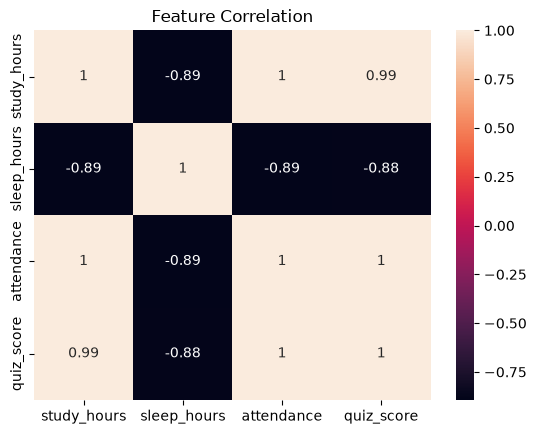

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df.corr(),
    annot=True
)

plt.title("Feature Correlation")
plt.show()

# Step 2 — Scale the Features

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

# Step 3 — Find Optimal K

In [5]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

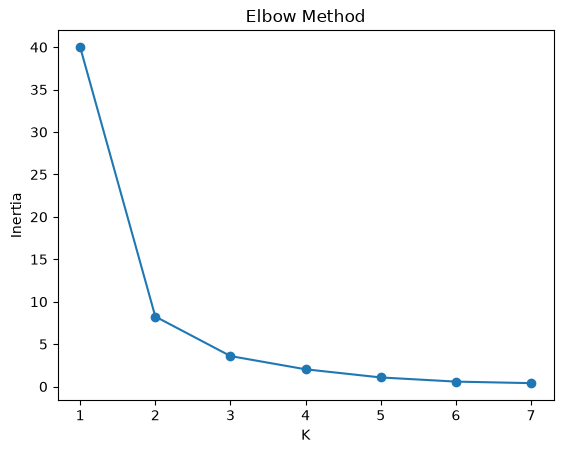

In [6]:
plt.plot(
    range(1, 8),
    inertias,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# Step 4 — Train K-Means

In [7]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print(df)

   study_hours  sleep_hours  attendance  quiz_score  cluster
0            1            8          60          50        2
1            2            7          65          55        2
2            2            8          62          52        2
3            3            7          70          60        0
4            7            6          90          85        1
5            8            6          95          90        1
6            8            5          92          88        1
7            9            6          98          95        1
8            4            7          75          70        0
9            5            7          80          75        0


# Step 5 — Profile the Clusters

In [8]:
cluster_profile = df.groupby("cluster").mean()

print(cluster_profile)

         study_hours  sleep_hours  attendance  quiz_score
cluster                                                  
0           4.000000     7.000000   75.000000   68.333333
1           8.000000     5.750000   93.750000   89.500000
2           1.666667     7.666667   62.333333   52.333333


Step 6 — Visualize

Use PCA to reduce the four features to two dimensions:

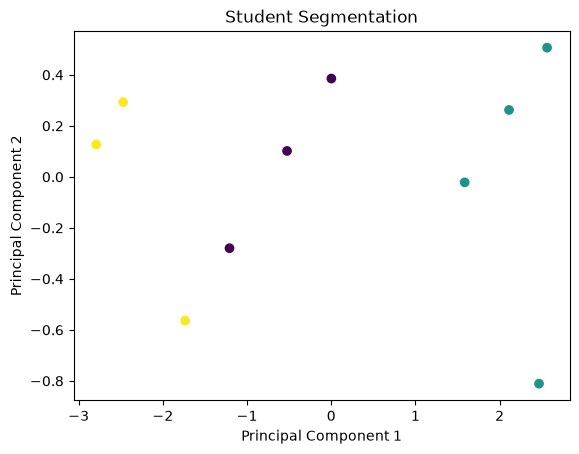

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Student Segmentation")

plt.show()